## Brique retrieval — mini RAG sur les bases vectorielles

Objectif : donner du texte ou une image en requete, retrouver les illustrations les
plus proches dans les deux bases vectorielles SigLIP construites dans
`vector_base.ipynb` (Bibles `classes_celine` + Ovide `BNU_corpus`). C'est la premiere
brique d'un mini RAG (Retrieval-Augmented Generation) : ici seulement la partie
*retrieval* (recherche), la partie *generation* (un LLM qui exploite les resultats)
viendra dans un second temps.

SigLIP a un avantage sur DINOv2 pour ce cas d'usage : ses deux tours (image et texte)
partagent le meme espace vectoriel, donc une requete texte est directement comparable
aux embeddings image deja stockes — pas besoin de re-vectoriser les bases.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

RACINE = Path("../../").resolve()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

Device : cuda


### 1. Index unifie (Bibles + Ovide)

On recharge les deux bases vectorielles deja construites et on les concatene en un
seul index, avec une colonne `source` (`bible` / `ovide`) pour pouvoir filtrer ou
distinguer les resultats.

In [2]:
DOSSIER_VECTOR_DB = RACINE / "data" / "vector_bases"

base_bibles = pd.read_pickle(DOSSIER_VECTOR_DB / "bibles_siglip.pkl")
base_bibles["source"] = "bible"

base_ovide = pd.read_pickle(DOSSIER_VECTOR_DB / "ovide_corpus_complet_siglip.pkl")
base_ovide["source"] = "ovide"

# ovide_corpus_complet_siglip.pkl (2191 illustrations, 28 editions) remplace
# ovide_bnu_corpus_siglip.pkl (73) : mêmes 73 thèmes connus conservés, ~2100 de
# plus sans thème individuel mais avec les métadonnées d'édition (Synthèse
# BNU_corpus.ods). reindex() plutôt que selection directe : cette base n'a pas
# les colonnes url_page/url_image (deviennent NaN).
COLS_COMMUNES = ["chemin", "source", "theme", "embedding", "embedding_metadonnees",
                  "url_page", "url_image"]
COLS_OVIDE_EXTRA = ["titre", "ville", "annee", "graveur", "technique",
                     "type_iconographique", "famille_iconographique",
                     "theme_precis", "description_planche"]
index = pd.concat([
    base_bibles.reindex(columns=COLS_COMMUNES + COLS_OVIDE_EXTRA),
    base_ovide.reindex(columns=COLS_COMMUNES + COLS_OVIDE_EXTRA),
], ignore_index=True)
X_index = np.array(index["embedding"].tolist())
X_index_meta = np.array(index["embedding_metadonnees"].tolist())

print(f"Index unifie : {len(index)} illustrations "
      f"({(index['source'] == 'bible').sum()} Bibles, {(index['source'] == 'ovide').sum()} Ovide), "
      f"embeddings {X_index.shape}")

from sentence_transformers import SentenceTransformer

modele_e5 = SentenceTransformer("intfloat/multilingual-e5-small")
print("Modele e5 charge")

Index unifie : 2661 illustrations (470 Bibles, 2191 Ovide), embeddings (2661, 768)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modele e5 charge


### 1bis. Modele texte-texte pour les metadonnees (e5)

SigLIP n'est entraine qu'a comparer image<->texte, pas texte<->texte : reutiliser SigLIP pour indexer les metadonnees (titre, graveur, theme...) donne de mauvais resultats (verifie empiriquement). `multilingual-e5-small` est concu pour ca.

### 2. Modele SigLIP complet (texte + image, meme espace)

`vector_base.ipynb` utilisait `SiglipVisionModel` (tour vision seule) pour construire
les bases. Pour encoder des requetes texte il faut le modele complet (`AutoModel`,
tours vision + texte). Deux points verifies avant de s'en servir :

- SigLIP n'a **pas** de couche de projection separee comme CLIP : le `pooler_output`
  de la tour vision seule est deja l'embedding partage utilise pour le calcul de
  similarite image/texte (verifie : `pooler_output` normalise == `image_embeds` du
  modele complet, egalite stricte). Les embeddings deja stockes dans les bases
  restent donc valides, pas besoin de les recalculer.
- Remarque technique (`transformers` 5.6.2 ici) : `get_text_features()` et
  `get_image_features()` renvoient un objet de sortie complet (`.pooler_output` a
  extraire) plutot qu'un tenseur directement — a verifier si l'environnement est mis
  a jour un jour, ce comportement a change entre versions de `transformers`.

In [3]:
from transformers import AutoProcessor, AutoModel

NOM_MODELE = "google/siglip-base-patch16-224"
processor = AutoProcessor.from_pretrained(NOM_MODELE)
model = AutoModel.from_pretrained(NOM_MODELE).to(DEVICE).eval()
print("SigLIP complet (texte + image) charge")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP complet (texte + image) charge


### 3. Fonctions d'embedding requete (texte / image)

In [4]:
def embed_texte(requete):
    """Encode une requete texte dans le meme espace que les embeddings image de l'index."""
    inputs = processor(text=[requete], padding="max_length", return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        vec = model.get_text_features(**inputs).pooler_output
    return vec.cpu().numpy()[0]


def embed_image(chemin_ou_image):
    """Encode une image requete (meme pretraitement niveaux de gris que pour l'index,
    pour neutraliser le coloriage comme dans vector_base.ipynb)."""
    img = chemin_ou_image if isinstance(chemin_ou_image, Image.Image) else Image.open(chemin_ou_image)
    img = img.convert("RGB").convert("L").convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        vec = model.get_image_features(**inputs).pooler_output
    return vec.cpu().numpy()[0]

### 4. Fonction de recherche (retrieval)

In [5]:
def rechercher(vecteur_requete, k=5, source=None):
    """Top-k illustrations de l'index les plus proches (cosinus) d'un vecteur requete.
    source : None (tout l'index), "bible" ou "ovide" pour restreindre la recherche."""
    sous_index = index if source is None else index[index["source"] == source]
    X = X_index if source is None else X_index[sous_index.index.to_numpy()]
    sims = cosine_similarity(vecteur_requete.reshape(1, -1), X)[0]
    ordre = sims.argsort()[::-1][:k]
    resultats = sous_index.iloc[ordre].copy()
    resultats["similarite"] = sims[ordre]
    return resultats.reset_index(drop=True)

### Recherche hybride (visuel + metadonnees)

Pour les requetes texte uniquement (pas d'equivalent metadonnees pour une image uploadee).

In [6]:
# colonnes de faits exacts (ville/graveur/technique) : la similarite semantique
# seule confond des mots proches (ex. "Lyon" faisait remonter "Hippomene en
# Lion") — un mot de la requete qui matche mot-pour-mot une valeur de ces
# colonnes est un signal beaucoup plus fort qu'une similarite d'embedding.
COLONNES_FILTRABLES = ["ville", "graveur", "technique"]


def _normaliser(s):
    import unicodedata
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return s.lower()


def masque_correspondance_exacte(requete_texte):
    """Pour chaque colonne filtrable, verifie si un mot significatif (>=4
    caracteres) de la valeur de cette colonne apparait comme mot entier dans la
    requete (insensible a la casse/accents). Retourne un masque booleen : au
    moins une correspondance exacte pour cette ligne."""
    import re
    q_norm = _normaliser(requete_texte)
    mots_requete = set(re.findall(r"\w+", q_norm))

    masque = np.zeros(len(index), dtype=bool)
    for col in COLONNES_FILTRABLES:
        valeurs = index[col]
        for i, val in enumerate(valeurs):
            if pd.isna(val) or masque[i]:
                continue
            mots_valeur = re.findall(r"\w+", _normaliser(val))
            if any(len(m) >= 4 and m in mots_requete for m in mots_valeur):
                masque[i] = True
    return masque


def rechercher_hybride(requete_texte, k=5, k_rrf=60):
    """Combine similarite visuelle (SigLIP), similarite metadonnees (e5) et
    correspondance exacte (ville/graveur/technique) par Reciprocal Rank Fusion
    — SigLIP seul donnait de mauvais resultats sur des requetes
    factuelles/thematiques (ex. "Cadmus combat un serpent" faisait remonter un
    document Cain et Abel avant le bon document), car il n'est entraine que
    pour comparer image<->texte, jamais texte<->texte. La RRF combine des
    rangs, pas des scores bruts — insensible aux echelles tres differentes
    entre SigLIP (~0.1-0.2) et e5 (~0.75-0.85). La correspondance exacte est
    traitee comme un 3e "classement" (rang 1 si match, dernier rang sinon)
    plutot que comme un filtre dur, pour rester tolerant si aucune ligne ne
    matche exactement (ex. "Cadmus combat un serpent" : aucun mot de
    ville/graveur/technique, la RRF retombe alors sur visu+meta seuls)."""
    v_visuel = embed_texte(requete_texte)
    v_meta = modele_e5.encode([f"query: {requete_texte}"], normalize_embeddings=True)[0]

    sims_visu = cosine_similarity(v_visuel.reshape(1, -1), X_index)[0]
    sims_meta = cosine_similarity(v_meta.reshape(1, -1), X_index_meta)[0]
    masque_exact = masque_correspondance_exacte(requete_texte)

    rangs_visu = (-sims_visu).argsort().argsort() + 1
    rangs_meta = (-sims_meta).argsort().argsort() + 1
    rang_exact = np.where(masque_exact, 1, len(index))
    score_rrf = 1 / (k_rrf + rangs_visu) + 1 / (k_rrf + rangs_meta) + 1 / (k_rrf + rang_exact)

    ordre = np.argsort(-score_rrf)[:k]
    resultats = index.iloc[ordre].copy()
    resultats["similarite"] = sims_visu[ordre]
    resultats["sim_metadonnees"] = sims_meta[ordre]
    resultats["correspondance_exacte"] = masque_exact[ordre]
    resultats["score_rrf"] = score_rrf[ordre]
    return resultats.reset_index(drop=True)


### 5. Affichage des resultats

In [7]:
def libelle_resultat(row):
    """Etiquette d'affichage : le theme si connu, puis le theme precis
    (planche par planche, Solis/Salomon), sinon les metadonnees d'edition
    disponibles (graveur, annee) plutot que de reduire a un simple "sans theme"."""
    if pd.notna(row.theme):
        return str(row.theme)
    if pd.notna(getattr(row, "theme_precis", None)):
        return str(row.theme_precis)
    if row.source == "ovide":
        morceaux = []
        graveur = getattr(row, "graveur", None)
        if pd.notna(graveur):
            morceaux.append(str(graveur).split(",")[0].strip())
        annee = getattr(row, "annee", None)
        if pd.notna(annee):
            morceaux.append(str(annee))
        if morceaux:
            return ", ".join(morceaux)
    return "(sans theme)"


def afficher_grille(resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.6))
    axes = [axes] if n == 1 else axes
    for ax, (_, row) in zip(axes, resultats.iterrows()):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"[{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()


def afficher_avec_requete(chemin_requete, resultats, titre=""):
    n = len(resultats)
    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 2.2, 2.6))
    axes[0].imshow(Image.open(chemin_requete).convert("RGB"))
    axes[0].set_title("requete", fontsize=8)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    for ax, (_, row) in zip(axes[1:], resultats.iterrows()):
        ax.imshow(Image.open(row["chemin"]).convert("RGB"))
        ax.set_title(f"[{row['source']}] {libelle_resultat(row)}\n{row['similarite']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(titre, fontsize=10)
    plt.tight_layout()
    plt.show()

### Demo — requetes texte (anglais)

Quatre themes bien representes cote Bibles, requetes en anglais (voir plus bas pour
le constat en francais).

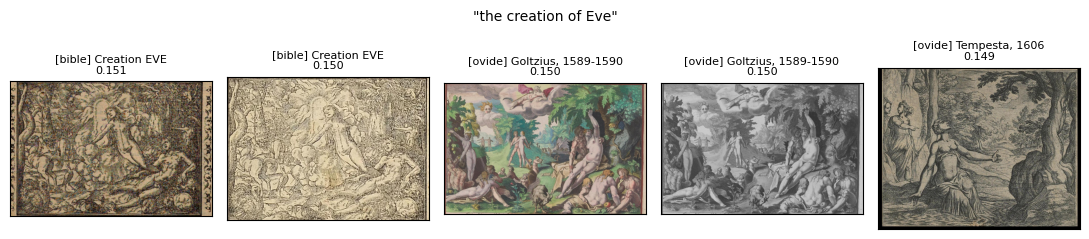

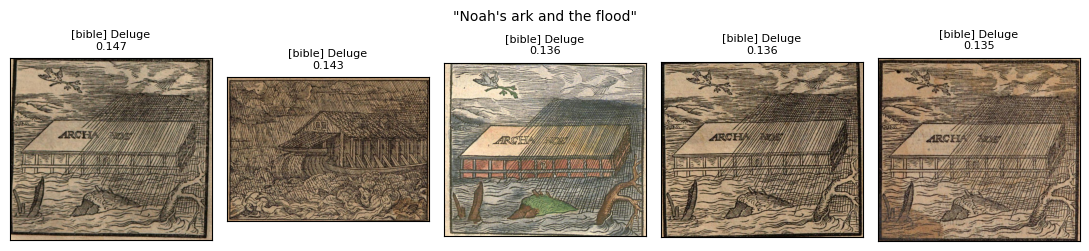

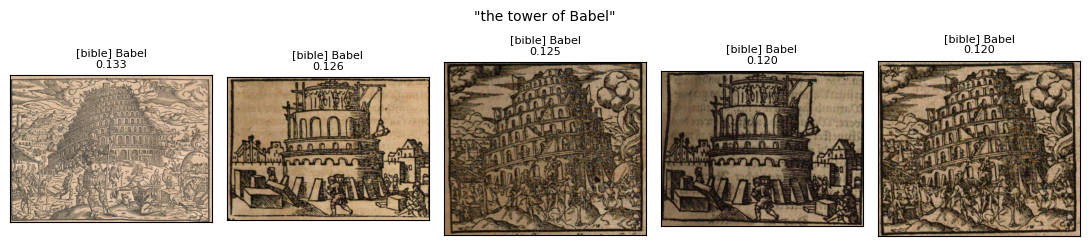

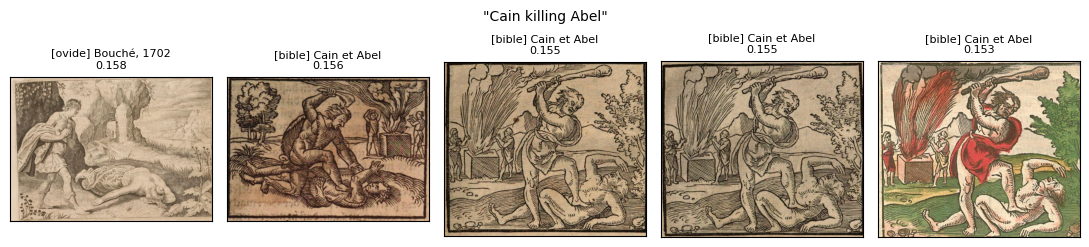

In [8]:
REQUETES_EN = [
    "the creation of Eve",
    "Noah's ark and the flood",
    "the tower of Babel",
    "Cain killing Abel",
]

for requete in REQUETES_EN:
    v = embed_texte(requete)
    resultats = rechercher(v, k=5)
    afficher_grille(resultats, titre=f'"{requete}"')

**A propos des scores** : les similarites texte->image ci-dessus (~0.10-0.16) sont
beaucoup plus basses en valeur absolue que les similarites image->image plus bas
(~0.9+). C'est une caracteristique connue de l'espace SigLIP (entraine avec une perte
sigmoid, pas un softmax contrastif comme CLIP) — ce qui compte est le **classement
relatif** des resultats, pas la valeur absolue du score.

### Demo — requetes texte (francais)

Meme test en francais, pour objectiver l'ecart avant de decider s'il faut traduire
les requetes.

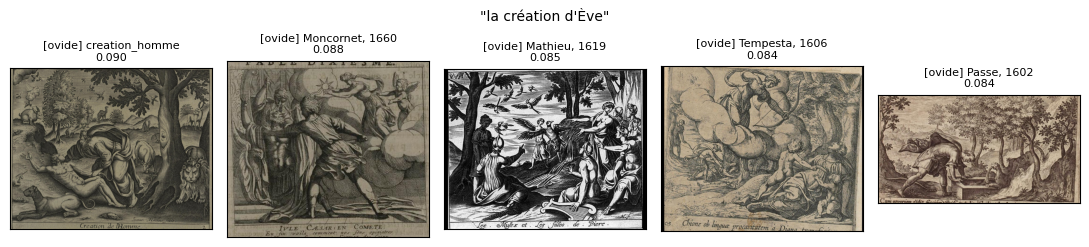

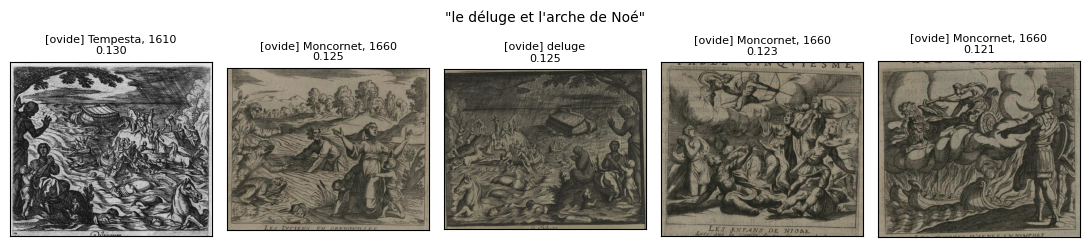

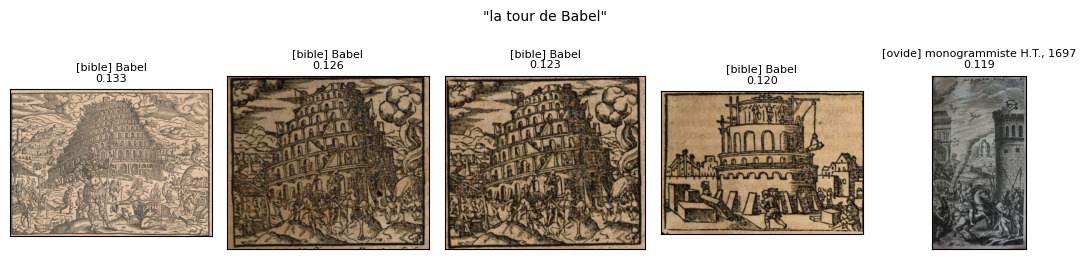

In [9]:
REQUETES_FR = [
    "la création d'Ève",
    "le déluge et l'arche de Noé",
    "la tour de Babel",
]

for requete in REQUETES_FR:
    v = embed_texte(requete)
    resultats = rechercher(v, k=5)
    afficher_grille(resultats, titre=f'"{requete}"')

**Constat** : "la tour de Babel" reste correcte, mais "la création d'Ève" tombe
a cote (aucun resultat du theme `Creation EVE` dans le top 5) et le deluge est moins
net qu'en anglais. `google/siglip-base-patch16-224` est entraine sur WebLI,
majoritairement anglophone.

**Mitige depuis par la recherche hybride** (voir plus bas) : `rechercher_hybride()`
combine ce signal visuel avec un second index texte (`multilingual-e5-small`,
entraine multilingue) par Reciprocal Rank Fusion. Dans l'appli finale (`app_rag.py`),
toute requete texte passe par cette recherche hybride, pas par SigLIP seul — la
limite ci-dessus reste vraie pour la brique visuelle isolee, mais n'empeche plus le
francais de bien fonctionner en pratique (voir les requetes de test dans le
README).

### Demo — requete image (sanity check leave-one-out)

On reprend une illustration deja presente dans l'index, on la retire de l'index, on
la reencode comme une requete "fraiche", et on verifie que ses plus proches voisines
restantes partagent bien le meme theme. Sert a valider que le pipeline d'encodage
requete est bien coherent avec celui utilise pour construire la base.

Requete : bsb00085642_page031_det1_conf0.92.jpg  (theme attendu : Babel)


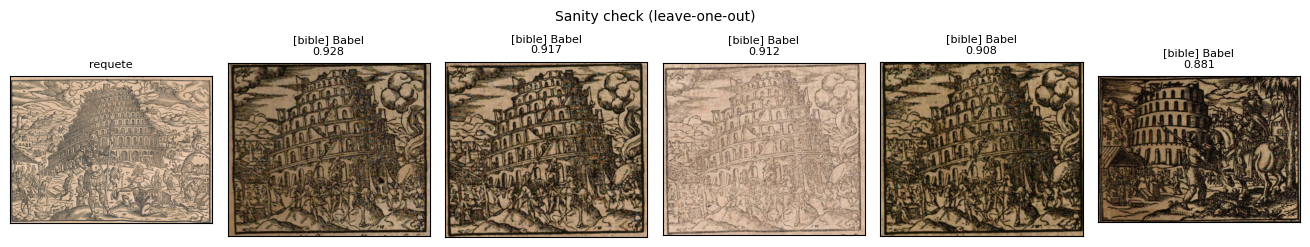

In [10]:
ligne_test = index.iloc[0]
index_sans_requete = index.drop(index.index[0]).reset_index(drop=True)
X_sans_requete = np.delete(X_index, 0, axis=0)

v_img = embed_image(ligne_test["chemin"])
sims = cosine_similarity(v_img.reshape(1, -1), X_sans_requete)[0]
ordre = sims.argsort()[::-1][:5]
resultats_loo = index_sans_requete.iloc[ordre].copy()
resultats_loo["similarite"] = sims[ordre]

print(f"Requete : {Path(ligne_test['chemin']).name}  (theme attendu : {ligne_test['theme']})")
afficher_avec_requete(ligne_test["chemin"], resultats_loo, titre="Sanity check (leave-one-out)")

### Demo — requete image hors base (planches Salomon)

Memes pages "themes connus" utilisees dans `vector_base.ipynb` pour la comparaison
CLIP/DINOv2/SigLIP.

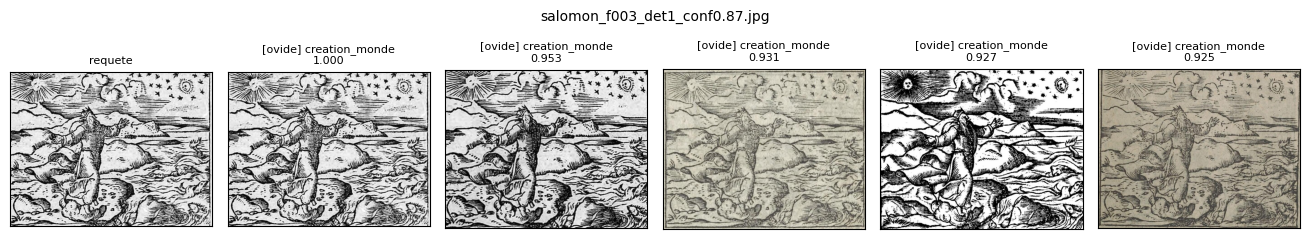

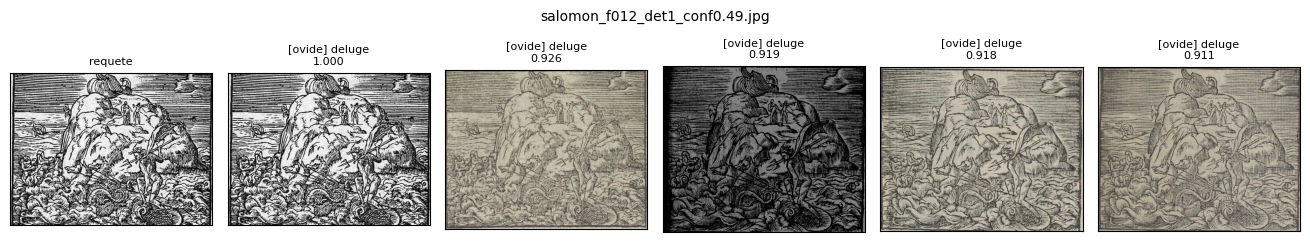

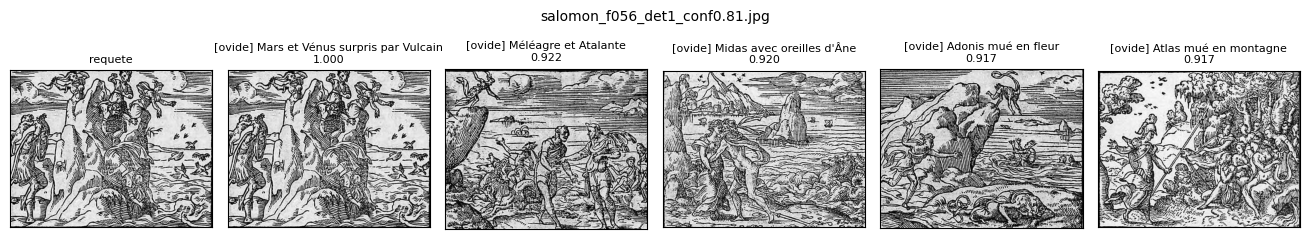

In [11]:
OVIDE_DIR = RACINE / "data" / "editions_ovide" / "segmentees" / "bois_salomon_rouille_lyon1557"

for page in ["f003", "f012", "f056"]:
    correspondances = sorted(OVIDE_DIR.glob(f"salomon_{page}_*.jpg"))
    if not correspondances:
        print(f"  ! aucune image trouvee pour {page}")
        continue
    chemin_requete = correspondances[0]
    v = embed_image(chemin_requete)
    resultats = rechercher(v, k=5)
    afficher_avec_requete(chemin_requete, resultats, titre=chemin_requete.name)

### Demo — recherche hybride (avec filtre exact ville/graveur/technique)

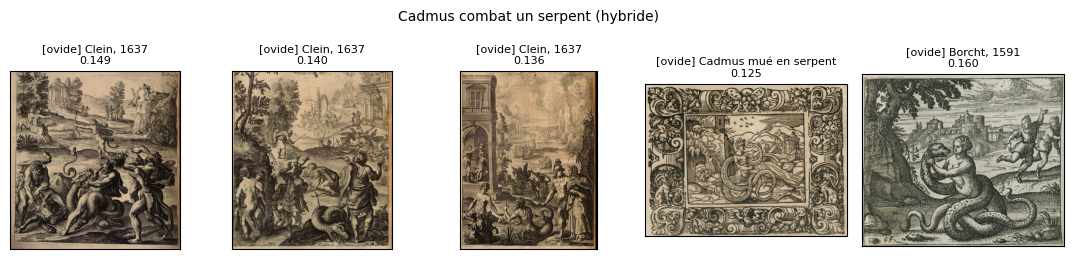

In [12]:
resultats = rechercher_hybride("Cadmus combat un serpent", k=5)
afficher_grille(resultats, titre="Cadmus combat un serpent (hybride)")

## Bilan de la brique retrieval

- **Image -> image** : tres fiable (voisin de meme theme quasi systematique, y
  compris a travers des editions differentes).
- **Texte (anglais) -> image, SigLIP seul** : fiable sur les 4 themes testes (Eve,
  deluge, Babel, Cain et Abel) — classement correct malgre des scores bas en valeur
  absolue.
- **Texte (francais) -> image, SigLIP seul** : moins fiable avec ce checkpoint non
  multilingue — mitige par la recherche hybride (ci-dessus), qui reste la voie
  utilisee en pratique pour toute requete texte.
- **Limite structurelle observee** : sur une requete image, le voisinage tend a se
  regrouper d'abord par *type de corpus* (Bible vs Ovide, probablement via le style
  de gravure/mise en page) avant de se regrouper par theme — a garder en tete si le
  RAG doit un jour comparer avec des corpus externes non vus.
- **Recherche hybride et filtre exact** (ajoutes apres la premiere version de ce
  notebook) : `rechercher_hybride()` combine similarite visuelle, similarite
  metadonnees (e5) et correspondance exacte (ville/graveur/technique) par Reciprocal
  Rank Fusion — necessaire car SigLIP seul echoue sur les requetes factuelles
  ("Cadmus combat un serpent" faisait remonter un document Cain et Abel). Detail
  complet dans le README du dossier.

**Brique suivante** : `rag_generation.ipynb` branche un LLM (texte puis vision) sur
le top-k retourne ici pour rediger une reponse groundee, deja integre dans l'appli
de demo `app_rag.py`.